In [1]:
import numpy as np
import pandas as pd
import specdal
import os

import fiona
import json
import matplotlib.pyplot as plt

In [2]:
def read_prisma_reflectance_geopackage(filename, name="", measure_type="tgt_reflect",
                            scale=1.5259021896696422e-05):
    """ Esta función convierte un archivo con una firma espectral de PRISMA a el objeto
        Spectrum() de specdal"""
    wl_ref = [406.99341, 415.83899, 423.78476, 431.33469, 438.65689, 446.01471, 453.38947, 460.73175, 468.09842, 475.31885, 482.54816, 489.79486, 497.05865, 504.51172, 512.04639, 519.54376, 527.3053, 535.05255, 542.88513, 550.91461, 559.02026, 567.20612, 575.48682, 583.84412, 592.33899, 601.0144, 609.95819, 618.71997, 627.77844, 636.67627, 645.96381, 655.41876, 664.8941, 674.46436, 684.13727, 694.12836, 703.737, 713.72687, 723.87994, 733.9552, 744.14954, 754.4696, 764.85645, 775.2735, 785.65955, 796.12701, 806.71106, 817.31104, 827.91949, 838.52722, 849.20996, 859.97314, 870.74255, 881.45605, 892.08093, 902.80164, 913.44507, 923.9502, 934.11206, 944.62732, 956.27148, 967.02667, 977.36542, 943.35791, 951.40143, 959.974, 969.84491, 979.224, 988.91791, 998.9082, 1008.6443, 1018.5357, 1029.344, 1037.9878, 1047.675, 1057.5737, 1067.7948, 1078.2161, 1088.761, 1099.2776, 1109.8894, 1120.6759, 1131.3048, 1142.0703, 1152.6501, 1163.676, 1174.7142, 1185.5884, 1196.3394, 1207.2737, 1217.8635, 1229.1852, 1240.2145, 1250.9799, 1262.5322, 1273.4963, 1284.4878, 1295.4218, 1306.218, 1317.2566, 1328.2993, 1339.1294, 1349.7877, 1361.0531, 1372.9117, 1383.2798, 1394.754, 1405.6268, 1416.5374, 1427.3748, 1438.4659, 1449.1888, 1459.3157, 1469.9308, 1480.8422, 1491.4292, 1502.0236, 1512.6333, 1523.2222, 1533.7764, 1544.2262, 1554.8168, 1565.3688, 1575.6274, 1585.8597, 1596.2454, 1606.4913, 1616.8336, 1627.021, 1637.0919, 1647.2316, 1656.933, 1667.1851, 1677.3193, 1687.4269, 1697.2943, 1707.0945, 1716.8589, 1726.6516, 1736.4883, 1746.2192, 1755.833, 1765.5127, 1775.1178, 1784.7173, 1793.9531, 1803.5902, 1813.0514, 1822.4413, 1832.0272, 1841.3256, 1850.5543, 1859.5587, 1868.1732, 1878.7426, 1887.0811, 1896.0913, 1904.9347, 1914.3015, 1923.3857, 1932.2599, 1941.1107, 1949.9008, 1958.6244, 1967.3418, 1976.0129, 1984.853, 1993.5482, 2002.1106, 2010.6614, 2019.3214, 2027.7267, 2036.2607, 2044.6809, 2053.0078, 2061.3787, 2069.7957, 2077.9915, 2086.3823, 2094.6252, 2102.8213, 2111.0391, 2119.2314, 2127.3372, 2135.5103, 2143.4656, 2151.3862, 2159.564, 2167.4849, 2175.3442, 2183.4202, 2191.1003, 2199.1353, 2206.843, 2214.625, 2222.4263, 2230.0076, 2237.9041, 2245.4485, 2253.1104, 2260.8665, 2268.2883, 2276.0537, 2283.4934, 2290.8267, 2298.6094, 2305.7227, 2313.2007, 2320.8955, 2327.8242, 2335.5264, 2342.8228, 2349.7915, 2357.2937, 2364.5945, 2371.5522, 2378.771, 2386.0618, 2393.0388, 2400.0359, 2407.6045, 2414.3567, 2421.2373, 2428.6677, 2435.5442, 2442.4031, 2449.1423, 2456.5857, 2463.0303, 2469.6272, 2477.0549, 2483.793, 2490.2192, 2497.1155]
    # Creo la colección para guardar los datos
    collection = specdal.Collection(name=name,measure_type=measure_type)
    
    # Leemos el geopackge
    shape = fiona.open(filename)
    
    # Recorro todos los features
    for feature in shape:
        metadata = {}
        
        # Creo los metadatos
        metadata["name"] = feature["properties"]["name"]
        metadata["lat"], metadata["lon"] = feature["geometry"]["coordinates"]
        metadata["scale"] = scale
        
        # Leo los perfiles
        profiles = json.loads(feature["properties"]["profiles"])
        bbl = profiles["bbl"]
        x = profiles["x"]
        y = profiles["y"]

        # Convertimos los arrays a numpy
        wl = np.array(x)
        if x[0] is None: wl = np.array(wl_ref)
        rho = np.array(y)

        # Creamos el objeto spectrum
        measurement = pd.Series(data=rho*scale, index=wl)
        measurement.index.name = "wavelength"
        spectrum = specdal.Spectrum(measurement=measurement, name=metadata["name"], 
                                    measure_type=measure_type, metadata=metadata)
        
        collection.append(spectrum)
    shape.close()
    return collection

In [3]:
c = read_prisma_reflectance_geopackage("../datos/chajari_mayo2023/prisma/firmas_2023/firmas_2023_prisma_2puntos_lotesCE.gpkg")

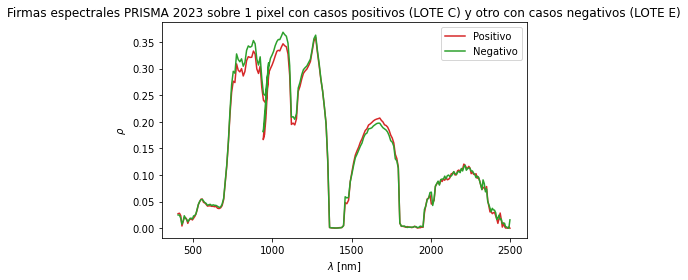

In [19]:
#c.plot()
c["Positivo"].plot(color="C3", label="Positivo")
c["Negativo"].plot(color="C2", label="Negativo")
plt.xlabel(r"$\lambda$ [nm]")
plt.ylabel(r"$\rho$")
plt.legend()
plt.title("Firmas espectrales PRISMA 2023 sobre 1 pixel con casos positivos (LOTE C) y otro con casos negativos (LOTE E)")

plt.tight_layout()
#plt.savefig("../figuras/chajari/imagen 2023/reflectancias_2puntos_lotesCE", bbox_inches="tight", dpi=300)
plt.savefig("../figuras/chajari/imagen 2023/figuras_titulo/reflectancias_2puntos_lotesCE", bbox_inches="tight", dpi=300)
#plt.savefig("../figuras/imagen_202204/202204_reflectancias.pdf", bbox_inches="tight")

plt.show()

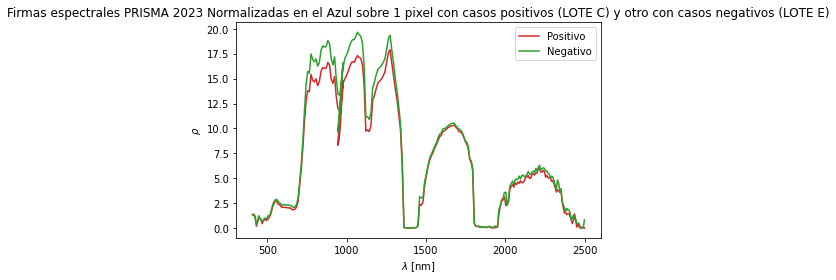

In [18]:
#c.plot() Normalizando en el Azul
c["Positivo"].normalize(453.38947, interpolate=True).plot(color="C3", label="Positivo")
c["Negativo"].normalize(453.38947, interpolate=True).plot(color="C2", label="Negativo")
plt.xlabel(r"$\lambda$ [nm]")
plt.ylabel(r"$\rho$")
plt.legend()
plt.title("Firmas espectrales PRISMA 2023 Normalizadas en el Azul sobre 1 pixel con casos positivos (LOTE C) y otro con casos negativos (LOTE E)")

plt.tight_layout()
#plt.savefig("../figuras/chajari/imagen 2023/reflectancias_2puntos_lotesCE_normAzul", bbox_inches="tight", dpi=300)
plt.savefig("../figuras/chajari/imagen 2023/figuras_titulo/reflectancias_2puntos_lotesCE_normAzul", bbox_inches="tight", dpi=300)

#plt.savefig("../figuras/imagen_202204/202204_reflectancias.pdf", bbox_inches="tight")

plt.show()

In [6]:
for spectra in c.spectra:
    print(spectra.metadata)

{'name': 'Positivo', 'lat': -57.92717340853543, 'lon': -30.80723723403254, 'scale': 1.5259021896696422e-05}
{'name': 'Negativo', 'lat': -57.92621156910067, 'lon': -30.807555279995285, 'scale': 1.5259021896696422e-05}


In [7]:
d = read_prisma_reflectance_geopackage("../datos/chajari_mayo2023/prisma/firmas_2023/firmas_2023_prisma_2puntos_lotesAD.gpkg")

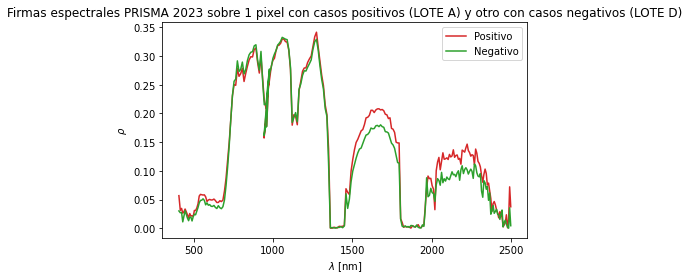

In [17]:
#c.plot()
d["Positivo"].plot(color="C3", label="Positivo")
d["Negativo"].plot(color="C2", label="Negativo")
plt.xlabel(r"$\lambda$ [nm]")
plt.ylabel(r"$\rho$")
plt.legend()
plt.title("Firmas espectrales PRISMA 2023 sobre 1 pixel con casos positivos (LOTE A) y otro con casos negativos (LOTE D)")

plt.tight_layout()
#plt.savefig("../figuras/chajari/imagen 2023/reflectancias_2puntos_lotesAD", bbox_inches="tight", dpi=300)
plt.savefig("../figuras/chajari/imagen 2023/figuras_titulo/reflectancias_2puntos_lotesAD", bbox_inches="tight", dpi=300)
#plt.savefig("../figuras/imagen_202204/202204_reflectancias.pdf", bbox_inches="tight")

plt.show()

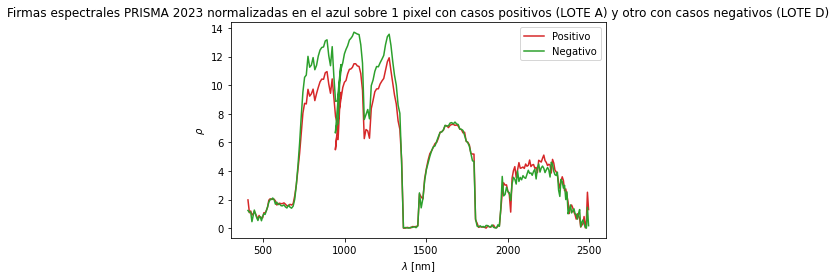

In [16]:
#d.plot() Normalizando en el Azul
d["Positivo"].normalize(453.38947, interpolate=True).plot(color="C3", label="Positivo")
d["Negativo"].normalize(453.38947, interpolate=True).plot(color="C2", label="Negativo")
plt.xlabel(r"$\lambda$ [nm]")
plt.ylabel(r"$\rho$")
plt.legend()
plt.title("Firmas espectrales PRISMA 2023 normalizadas en el azul sobre 1 pixel con casos positivos (LOTE A) y otro con casos negativos (LOTE D)")

plt.tight_layout()
#plt.savefig("../figuras/chajari/imagen 2023/reflectancias_2puntos_lotesAD_normAzul", bbox_inches="tight", dpi=300)
plt.savefig("../figuras/chajari/imagen 2023/figuras_titulo/reflectancias_2puntos_lotesAD_normAzul", bbox_inches="tight", dpi=300)

#plt.savefig("../figuras/imagen_202204/202204_reflectancias.pdf", bbox_inches="tight")

plt.show()